In [2]:
import loos
from loos import pyloos as pl
from pathlib import Path
import matplotlib.pyplot as plt
from enspara import msm
import numpy as np

def interdomain_distances(group_a, group_b, traj):
    distances = []
    traj.reset()
    while next(traj, False):
        cen_a = group_a.centroid()
        cen_b = group_b.centroid()
        dist = cen_a.distance(cen_b)
        distances.append(dist)
    return np.array(distances)

def interdomain_contact_sum(group_a, group_b, traj, contact_rad=3.5):
    contact_count = []
    traj.reset()
    while next(traj, False):
        contactors_a = group_a.within(contact_rad, group_b)
        contactors_b = group_b.within(contact_rad, group_a)
        total = len(contactors_a) + len(contactors_b)
        contact_count.append(total)
    return np.array(contact_count)

def contact_onto(target_group, query_group, traj, contact_rad=3.5):
    contact_count = []
    traj.reset()
    while next(traj, False):
        contactors = query_group.within(contact_rad, target_group)
        total = len(contactors)
        contact_count.append(total)
    return np.array(contact_count)


# from SO: https://stackoverflow.com/questions/48999542/more-efficient-weighted-gini-coefficient-in-python
def gini(x, w=None):
    # The rest of the code requires numpy arrays.
    x = np.asarray(x)
    if w is not None:
        print('using weights')
        w = np.asarray(w)
        sorted_indices = np.argsort(x)
        sorted_x = x[sorted_indices]
        sorted_w = w[sorted_indices]
        # Force float dtype to avoid overflows
        cumw = np.cumsum(sorted_w, dtype=float)
        cumxw = np.cumsum(sorted_x * sorted_w, dtype=float)
        return (np.sum(cumxw[1:] * cumw[:-1] - cumxw[:-1] * cumw[1:]) /
                (cumxw[-1] * cumw[-1]))
    else:
        sorted_x = np.sort(x)
        n = len(x)
        cumx = np.cumsum(sorted_x, dtype=float)
        # The above formula, with all weights equal to 1 simplifies to:
        return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

In [12]:
picked_models_p = Path('msms')
cluster_p = Path('rmsd-clustering-2025-12-02')
figdirp = Path('figures')
datadirp = figdirp/'data'
if not datadirp.is_dir():
    datadirp.mkdir()
model_p = picked_models_p/'PCBP1-wt-short-rad-0.30'
probs = np.load(model_p/'eq-probs.npy')
cens_dir = cluster_p/f'{model_p.name}/centers'
sm = loos.createSystem(str(cens_dir/'center0.pdb'))
trj = pl.Trajectory(str(cens_dir/'centers.dcd'), sm)
print(len(trj))

37


Warning - unknown PDB record 'MODEL'


In [5]:
a_domain = loos.selectAtoms(sm, 'resid < 93 && resid > 12')
b_domain = loos.selectAtoms(sm, 'resid > 93 && resid < 174')
dists = interdomain_distances(a_domain, b_domain, trj)
print(dists)
pdbA = loos.PDB.fromAtomicGroup(a_domain)
outA = Path('test-a-pcbp.pdb')
outA.write_text(str(pdbA))

[17.79613253 17.03778122 17.35368499 17.15618137 16.8581764  17.08836666
 17.57572018 17.13250852 16.76340597 16.85420622 17.15911207 16.82151853
 17.21354161 16.49357237 17.00627036 16.7594394  17.25966768 16.6195627
 17.1351288  17.74620743 17.44451271 16.77496285 17.03003697 17.35652979
 17.16386639 16.42697428 16.90881353 17.1646412  17.01424467 16.95528348
 17.33423802 16.76992604 16.88410217 17.04412786 17.23420743 17.51354481
 17.32598167]


101196

In [6]:
mutres = loos.selectAtoms(sm, 'resid == 101')
contacted = a_domain.within(3.5, mutres)
reses = contacted.splitByResidue()
print(*(f'{i[0].resname()}{i[0].resid()}' for i in reses))
print(len(contacted))

LEU19 MET21 PHE73 ILE76 ILE77 LEU80
18


86
[17.38543108 17.52512718 16.85389175 17.05218528 17.4314722  17.31108254
 17.50615999 17.21875716 17.13797467 17.11760718 17.43623598 16.83930022
 17.37622159 16.9424462  17.15625401 17.50365892 17.25525159 17.32463373
 17.59907187 16.96954094 17.31509607 16.8731035  17.60535653 17.10337192
 17.1227282  17.82289797 17.77546138 17.59307609 16.82217415 17.37949575
 17.21387766 16.88400248 17.13294299 17.49862699 18.16977729 17.69431731
 16.95321771 17.52036921 17.86236946 17.58271268 16.93089338 17.1992022
 16.88433562 17.55131363 17.09222297 17.27672075 16.79757572 17.51200055
 17.69792264 17.6613794  17.55465025 17.20904554 17.27296289 16.94163436
 17.04259549 17.63436199 16.74745196 16.98779046 17.84486915 17.35138319
 16.930746   16.79659029 16.773829   17.05531696 17.35014895 17.34723086
 16.94486732 16.96600286 17.15530091 17.35318576 16.848319   17.27149747
 16.9587741  18.28839956 17.2021164  17.44874159 17.42348474 17.77817744
 17.14424286 17.55707506 16.61459445 17.57157203 

<>:17: SyntaxWarning: invalid escape sequence '\A'
<>:17: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2109740/839246158.py:17: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel('Distance between domain centroids, $\AA$')
Warning - unknown PDB record 'MODEL'


Text(0, 0.5, 'Frequency in MSM')

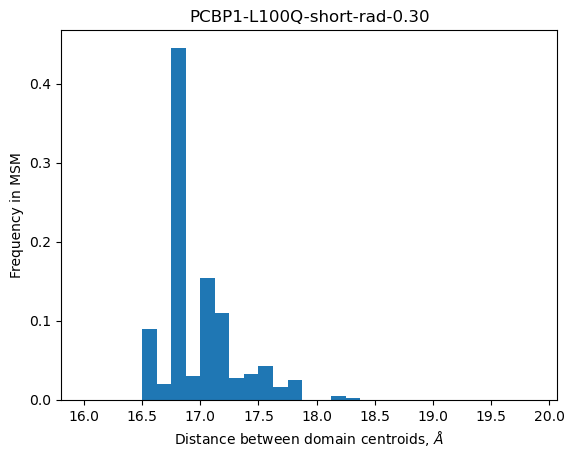

In [7]:
model_p = picked_models_p/'PCBP1-L100Q-short-rad-0.30'
probs = np.load(model_p/'eq-probs.npy')
cens_dir = cluster_p/f'{model_p.name}/centers'
sm = loos.createSystem(str(cens_dir/'center0.pdb'))
trj = pl.Trajectory(str(cens_dir/'centers.dcd'), sm)
print(len(trj))
a_domain = loos.selectAtoms(sm, 'resid < 93 && resid > 12')
b_domain = loos.selectAtoms(sm, 'resid > 93 && resid < 174')
dists = interdomain_distances(a_domain, b_domain, trj)
print(dists)
# pdbA = loos.PDB.fromAtomicGroup(a_domain)
# outA = Path('test-a-pcbp.pdb')
# outA.write_text(str(pdbA))
fig, ax = plt.subplots()
ax.hist(dists, weights=probs, bins=np.arange(16, 20, 0.125))
ax.set_title(f'{model_p.name}')
ax.set_xlabel('Distance between domain centroids, $\AA$')
ax.set_ylabel('Frequency in MSM')

In [8]:
domain_a_selstrs = {
    'PCBP1-L100Q-short-rad-0.30': 'resid < 93 && resid > 12',
    'PCBP1-wt-short-rad-0.30': 'resid < 93 && resid > 12',
    'UP1-M72I-short-rad-0.30': 'resid < 93 && resid > 10',
    'UP1-WT-short-rad-0.30': 'resid < 93 && resid > 10',
    'hnRNP_A2B1-D76H-rad-0.30': 'resid < 93 && resid > 10',
    'hnRNP_A2B1-D76N-rad-0.30': 'resid < 91 && resid > 2',
    'hnRNP_A2B1-D76V-rad-0.30': 'resid < 91 && resid > 2',
    'hnRNP_A2B1-WT-rad-0.30': 'resid < 91 && resid > 2'
}

domain_b_selstrs = {
    'PCBP1-L100Q-short-rad-0.30': 'resid > 93 && resid < 174',
    'PCBP1-wt-short-rad-0.30': 'resid > 93 && resid < 174',
    'UP1-M72I-short-rad-0.30': 'resid > 93 && resid < 182',
    'UP1-WT-short-rad-0.30': 'resid > 93 && resid < 182',
    'hnRNP_A2B1-D76H-rad-0.30': 'resid > 91 && resid < 174',
    'hnRNP_A2B1-D76N-rad-0.30':'resid > 91 && resid < 174',
    'hnRNP_A2B1-D76V-rad-0.30':'resid > 91 && resid < 174',
    'hnRNP_A2B1-WT-rad-0.30':  'resid > 91 && resid < 174'
}

mutant_resi = {
    'PCBP1-L100Q-short-rad-0.30': 'resid == 101',
    'PCBP1-wt-short-rad-0.30': 'resid == 101',
    'UP1-M72I-short-rad-0.30': 'resid == 73',
    'UP1-WT-short-rad-0.30': 'resid == 73',
    'hnRNP_A2B1-D76H-rad-0.30': 'resid == 63',
    'hnRNP_A2B1-D76N-rad-0.30':'resid == 63',
    'hnRNP_A2B1-D76V-rad-0.30':'resid == 63',
    'hnRNP_A2B1-WT-rad-0.30':  'resid == 63'
}

In [11]:
def format_residue_ends(ag):
    res = ag.splitByResidue()
    start_at = res[0][0]
    end_at = res[len(res) - 1][0]
    return ' '.join(map(str, ['start:', start_at.resname(), start_at.resid(), 'end:', end_at.resname(), end_at.resid()]))


for model_p in sorted(picked_models_p.iterdir()):
    model_n = model_p.name
    probs = np.load(model_p/'eq-probs.npy')
    cens_dir = cluster_p/f'{model_p.name}/centers'
    sm = loos.createSystem(str(cens_dir/'center0.pdb'))
    trj = pl.Trajectory(str(cens_dir/'centers.dcd'), sm)
    print(model_n, 'number of clusters', len(trj))
    a_domain = loos.selectAtoms(sm, domain_a_selstrs[model_n])
    b_domain = loos.selectAtoms(sm, domain_b_selstrs[model_n])
    print('a domain termini:', format_residue_ends(a_domain))
    print('b domain termini:', format_residue_ends(b_domain))

PCBP1-L100Q-short-rad-0.30 number of clusters 86
a domain termini: start: VAL 13 end: THR 92
b domain termini: start: ALA 94 end: GLN 173
PCBP1-wt-short-rad-0.30 number of clusters 37
a domain termini: start: VAL 13 end: THR 92
b domain termini: start: ALA 94 end: GLN 173
UP1-M72I-short-rad-0.30 number of clusters 43
a domain termini: start: PRO 11 end: SER 92
b domain termini: start: GLU 94 end: ALA 181
UP1-WT-short-rad-0.30 number of clusters 35
a domain termini: start: PRO 11 end: SER 92
b domain termini: start: GLU 94 end: ALA 181
hnRNP_A2B1-D76H-rad-0.30 number of clusters 171
a domain termini: start: PHE 11 end: PRO 92
b domain termini: start: PRO 92 end: LYS 173
hnRNP_A2B1-D76N-rad-0.30 number of clusters 73
a domain termini: start: GLU 3 end: GLY 90
b domain termini: start: PRO 92 end: LYS 173
hnRNP_A2B1-D76V-rad-0.30 number of clusters 222
a domain termini: start: GLU 3 end: GLY 90
b domain termini: start: PRO 92 end: LYS 173
hnRNP_A2B1-WT-rad-0.30 number of clusters 87
a doma

Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'


In [13]:
interdomain_dists_bymodel = {}
probs_bymodel = {}
for model_p in sorted(picked_models_p.iterdir()):
    model_n = model_p.name
    probs = np.load(model_p/'eq-probs.npy')
    probs_bymodel[model_n] = probs
    cens_dir = cluster_p/f'{model_p.name}/centers'
    sm = loos.createSystem(str(cens_dir/'center0.pdb'))
    trj = pl.Trajectory(str(cens_dir/'centers.dcd'), sm)
    print(model_n, 'number of clusters', len(trj))
    a_domain = loos.selectAtoms(sm, domain_a_selstrs[model_n])
    b_domain = loos.selectAtoms(sm, domain_b_selstrs[model_n])
    dists = interdomain_distances(a_domain, b_domain, trj)
    interdomain_dists_bymodel[model_n] = dists
    np.savetxt(datadirp/f'{model_n}-interdomain-dists.txt', dists)
    


PCBP1-L100Q-short-rad-0.30 number of clusters 86
PCBP1-wt-short-rad-0.30 number of clusters 37
UP1-M72I-short-rad-0.30 number of clusters 43
UP1-WT-short-rad-0.30 number of clusters 35
hnRNP_A2B1-D76H-rad-0.30 number of clusters 171
hnRNP_A2B1-D76N-rad-0.30 number of clusters 73
hnRNP_A2B1-D76V-rad-0.30 number of clusters 222
hnRNP_A2B1-WT-rad-0.30 number of clusters 87


Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'


In [17]:
interdomain_contacts_bymodel = {}
interface_contact_rad = 3.5  #angstroms
for model_p in sorted(picked_models_p.iterdir()):
    model_n = model_p.name
    cens_dir = cluster_p/f'{model_p.name}/centers'
    sm = loos.createSystem(str(cens_dir/'center0.pdb'))
    trj = pl.Trajectory(str(cens_dir/'centers.dcd'), sm)
    print(model_n, 'number of clusters', len(trj))
    a_domain = loos.selectAtoms(sm, f'!hydrogen && ({domain_a_selstrs[model_n]})')
    b_domain = loos.selectAtoms(sm, f'!hydrogen && ({domain_b_selstrs[model_n]})')
    contact_tallys = interdomain_contact_sum(a_domain, b_domain, trj, 
                                             contact_rad=interface_contact_rad)
    interdomain_contacts_bymodel[model_n] = contact_tallys
    np.savetxt(datadirp/f'{model_n}-interdomain-heavy-contacts.txt', contact_tallys)

Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'


PCBP1-L100Q-short-rad-0.30 number of clusters 86
PCBP1-wt-short-rad-0.30 number of clusters 37


Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'


UP1-M72I-short-rad-0.30 number of clusters 43
UP1-WT-short-rad-0.30 number of clusters 35


Warning - unknown PDB record 'MODEL'


...

hnRNP_A2B1-D76N-rad-0.30 number of clusters 73


Warning - unknown PDB record 'MODEL'


hnRNP_A2B1-D76V-rad-0.30 number of clusters 222


Warning - unknown PDB record 'MODEL'


hnRNP_A2B1-WT-rad-0.30 number of clusters 87


In [30]:
contacts_to_point_bymodel = {}
point_contact_rad = 3.5
for model_p in sorted(picked_models_p.iterdir()):
    model_n = model_p.name
    if 'PCBP1' in model_n:
        domain_selstrs = domain_a_selstrs
    else:
        domain_selstrs = domain_b_selstrs
    cens_dir = cluster_p /f'{model_p.name}/centers'
    sm = loos.createSystem(str(cens_dir/'center0.pdb'))
    trj = pl.Trajectory(str(cens_dir/'centers.dcd'), sm)
    print(model_n, 'number of clusters', len(trj))
    query_domain = loos.selectAtoms(sm, domain_selstrs[model_n])
    mutant_ag = loos.selectAtoms(sm, mutant_resi[model_n]) 
    contact_tallys = contact_onto(mutant_ag, query_domain, trj, contact_rad=point_contact_rad)
    contacts_to_point_bymodel[model_n] = contact_tallys
    np.savetxt(datadirp/f'{model_n}-interdomain-heavy-cto{point_contact_rad}-mutres.txt', contact_tallys)
print(contacts_to_point_bymodel['hnRNP_A2B1-WT-rad-0.30'])

PCBP1-L100Q-short-rad-0.30 number of clusters 86
PCBP1-wt-short-rad-0.30 number of clusters 37
UP1-M72I-short-rad-0.30 number of clusters 43
UP1-WT-short-rad-0.30 number of clusters 35
hnRNP_A2B1-D76H-rad-0.30 number of clusters 171
hnRNP_A2B1-D76N-rad-0.30 number of clusters 73
hnRNP_A2B1-D76V-rad-0.30 number of clusters 222
hnRNP_A2B1-WT-rad-0.30 number of clusters 87
[5 5 6 6 7 7 7 5 7 4 6 7 5 5 6 5 7 6 6 5 5 7 7 5 5 4 5 5 6 5 6 5 6 5 7 6 8
 7 8 7 7 5 6 7 7 5 5 5 7 5 6 7 4 7 6 7 5 5 5 5 7 7 7 7 7 8 6 5 7 7 7 5 6 6
 5 7 5 5 5 7 7 7 9 6 7 6 5]


Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'
Warning - unknown PDB record 'MODEL'


<>:24: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2109740/3554549210.py:24: SyntaxWarning: invalid escape sequence '\A'
  ax.set_ylabel('Distance, $\AA$')


hnRNP_A2B1-D76H-rad-0.30 31.020182925088875
using weights
hnRNP_A2B1-D76N-rad-0.30 28.781261377638664
using weights
hnRNP_A2B1-D76V-rad-0.30 51.80822847122891
using weights
hnRNP_A2B1-WT-rad-0.30 28.783127164622755
using weights
PCBP1-L100Q-short-rad-0.30 18.288399559397703
using weights
PCBP1-wt-short-rad-0.30 17.79613253488922
using weights
UP1-M72I-short-rad-0.30 29.737205546041924
using weights
UP1-WT-short-rad-0.30 29.323714105424074
using weights


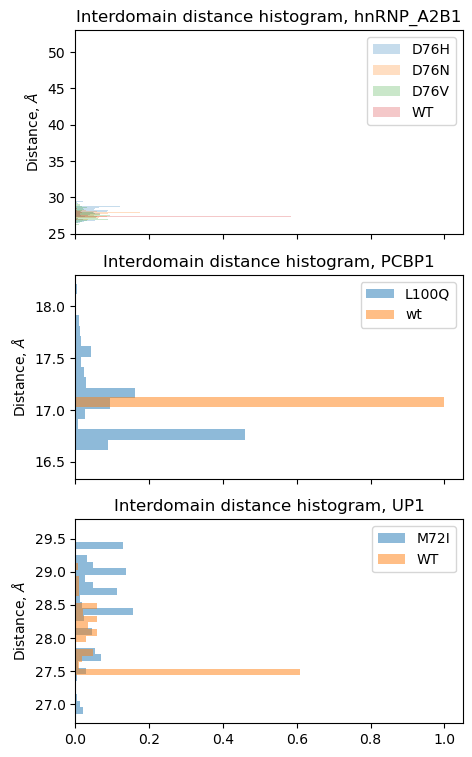

In [44]:
prots = ('hnRNP_A2B1', 'PCBP1', 'UP1')
fig, axs= plt.subplots(len(prots), 1, figsize=(5,9), sharex=True)
# bins = np.arange(10,25,0.125)
for i, protn in enumerate(prots):
    ax = axs[i]
    # ax.set_xscale('log')
    relvars = [k for k in interdomain_dists_bymodel if protn in k]
    for variant in relvars:
        varname = variant.split('-')[1]
        probs = probs_bymodel[variant]
        dists = interdomain_dists_bymodel[variant]
        # print(variant, dists)
        distmax = dists.max()
        distmin = dists.min()
        print(variant, distmax)
        bins = np.arange(distmin, distmax, 0.1)
        gini_score = gini(dists, w=probs)
        counts,_,_ = ax.hist(dists, bins=bins, weights=probs, label=varname, orientation='horizontal',
                 alpha=1/len(relvars))
        np.savetxt(datadirp/f'{variant}-interdomain-dists-bins.txt', bins)
        np.savetxt(datadirp/f'{variant}-interdomain-dists-counts.txt', counts)
    ax.set_title(f'Interdomain distance histogram, {protn}')
    ax.legend()
    ax.set_ylabel('Distance, $\AA$')
fig.savefig('figures/interdomain-dist-hists.pdf', transparent=True )

<>:23: SyntaxWarning: invalid escape sequence '\A'
<>:23: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2109740/2637198299.py:23: SyntaxWarning: invalid escape sequence '\A'
  ax.set_ylabel('Distance, $\AA$')


hnRNP_A2B1-D76H-rad-0.30 31.020182925088875
hnRNP_A2B1-D76N-rad-0.30 28.781261377638664
hnRNP_A2B1-D76V-rad-0.30 51.80822847122891
hnRNP_A2B1-WT-rad-0.30 28.783127164622755
PCBP1-L100Q-short-rad-0.30 18.288399559397703
PCBP1-wt-short-rad-0.30 17.79613253488922
UP1-M72I-short-rad-0.30 29.737205546041924
UP1-WT-short-rad-0.30 29.323714105424074


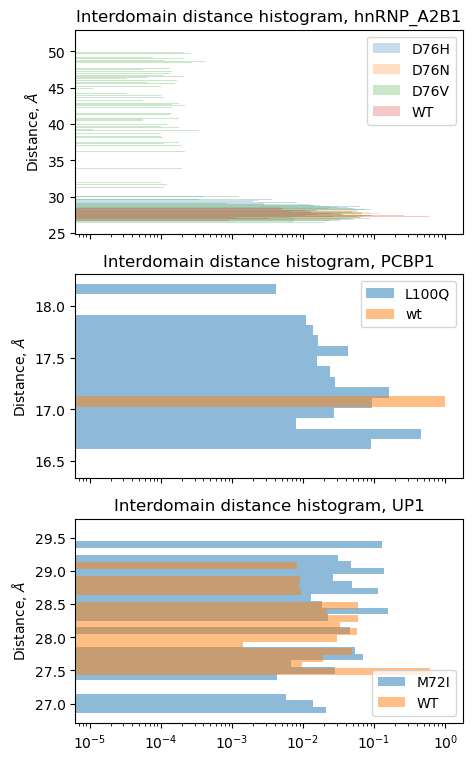

In [42]:
prots = ('hnRNP_A2B1', 'PCBP1', 'UP1')
fig, axs = plt.subplots(len(prots), 1, figsize=(5, 9), sharex=True)
# bins = np.arange(10,25,0.125)
for i, protn in enumerate(prots):
    ax = axs[i]
    ax.set_xscale('log')
    relvars = [k for k in interdomain_dists_bymodel if protn in k]
    for variant in relvars:
        varname = variant.split('-')[1]
        probs = probs_bymodel[variant]
        dists = interdomain_dists_bymodel[variant]
        # print(variant, dists)
        distmax = dists.max()
        distmin = dists.min()
        print(variant, distmax)
        bins = np.arange(distmin, distmax, 0.1)
        counts, _, _ = ax.hist(dists, bins=bins, weights=probs, label=varname, orientation='horizontal',
                alpha=1/len(relvars))
        np.savetxt(datadirp/f'{variant}-interdomain-dists-bins.txt', bins)
        np.savetxt(datadirp/f'{variant}-interdomain-dists-counts.txt', counts)    
    ax.set_title(f'Interdomain distance histogram, {protn}')
    ax.legend()
    ax.set_ylabel('Distance, $\AA$')
fig.savefig(figdirp/'interdomain-dist-hists-logscale.pdf', transparent=True)

hnRNP_A2B1-D76H-rad-0.30 31
hnRNP_A2B1-D76N-rad-0.30 31
hnRNP_A2B1-D76V-rad-0.30 31
hnRNP_A2B1-WT-rad-0.30 31


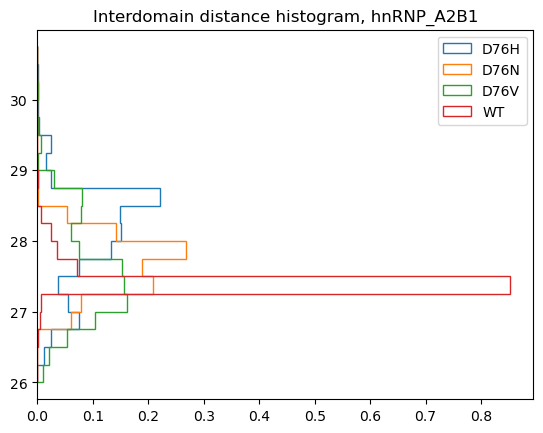

In [46]:
protn = 'hnRNP_A2B1'
relvars = [k for k in interdomain_dists_bymodel if protn in k]
fig, ax = plt.subplots()
# ax.set_xscale('log')
for variant in relvars:
    varname = variant.split('-')[1]
    probs = probs_bymodel[variant]
    dists = interdomain_dists_bymodel[variant]
    # print(variant, dists)
    distmax = 31
    distmin = np.floor(dists.min())
    print(variant, distmax)
    bins = np.arange(distmin, distmax, 0.25)
    ax.hist(dists, bins=bins, histtype='step', weights=probs,
            label=varname, orientation='horizontal')
    np.savetxt(datadirp/f'{variant}-onepanel-interdomain-dist-bins.txt', bins)
    np.savetxt(datadirp/f'{variant}-onepanel-interdomain-dist-counts.txt', counts)

ax.set_title(f'Interdomain distance histogram, {protn}')
ax.legend()
fig.savefig('figures/hnRNP_A2B1-interdist.pdf', transparent=True)

hnRNP_A2B1-D76H-rad-0.30 68.0
using weights
hnRNP_A2B1-D76N-rad-0.30 43.0
using weights
hnRNP_A2B1-D76V-rad-0.30 48.0
using weights
hnRNP_A2B1-WT-rad-0.30 50.0
using weights
PCBP1-L100Q-short-rad-0.30 48.0
using weights
PCBP1-wt-short-rad-0.30 58.0
using weights
UP1-M72I-short-rad-0.30 39.0
using weights
UP1-WT-short-rad-0.30 44.0
using weights


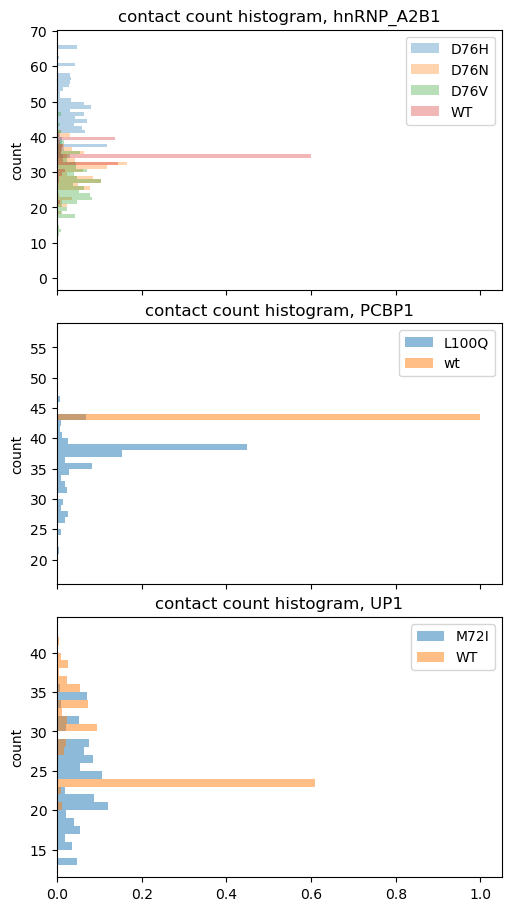

In [47]:
prots = ('hnRNP_A2B1', 'PCBP1', 'UP1')
fig, axs = plt.subplots(len(prots), 1, figsize=(5, 9), sharex=True, layout='constrained')
# bins = np.arange(10,25,0.125)
for i, protn in enumerate(prots):
    ax = axs[i]
    # ax.set_xscale('log')
    relvars = [k for k in interdomain_dists_bymodel if protn in k]
    for variant in relvars:
        varname = variant.split('-')[1]
        probs = probs_bymodel[variant]
        contact_tally = interdomain_contacts_bymodel[variant]
        # print(variant, dists)
        distmax = np.ceil(contact_tally.max())
        distmin = np.floor(contact_tally.min())
        print(variant, distmax)
        if len(relvars) > 2:
            alpha = 1/(len(relvars) - 1)
        else:
            alpha = 1/len(relvars)
        bins = np.arange(distmin, distmax, 1, dtype=int)
        gini_score = gini(contact_tally, w=probs)
        ax.hist(contact_tally, bins=bins, weights=probs, label=f'{varname}', orientation='horizontal',
                alpha=alpha)
        np.savetxt(datadirp/f'{variant}-intercontacts-bins.txt', bins)
        np.savetxt(datadirp/f'{variant}-intercontacts-counts.txt', counts)
    ax.set_title(f'contact count histogram, {protn}')
    ax.legend()
    ax.set_ylabel('count')
fig.savefig('figures/contact-count-hists.pdf', transparent=True)

hnRNP_A2B1-D76H-rad-0.30 68.0
hnRNP_A2B1-D76N-rad-0.30 43.0
hnRNP_A2B1-D76V-rad-0.30 48.0
hnRNP_A2B1-WT-rad-0.30 50.0


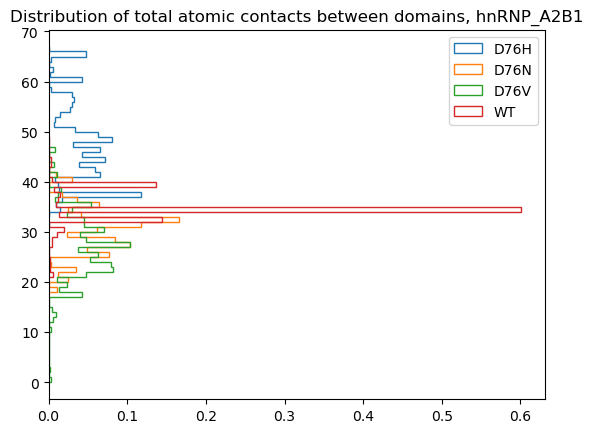

In [48]:
protn = 'hnRNP_A2B1'
relvars = [k for k in interdomain_dists_bymodel if protn in k]
fig, ax = plt.subplots()
# ax.set_xscale('log')
for variant in relvars:
    varname = variant.split('-')[1]
    probs = probs_bymodel[variant]
    contact_tallys = interdomain_contacts_bymodel[variant]
    # print(variant, dists)
    distmax = np.ceil(contact_tallys.max())
    distmin = np.floor(contact_tallys.min())
    print(variant, distmax)
    bins = np.arange(distmin, distmax, 1, dtype=int)
    ax.hist(contact_tallys, bins=bins, histtype='step', weights=probs,
            label=varname, orientation='horizontal')
    np.savetxt(datadirp/f'{variant}-onepanel-intercontacts-bins.txt', bins)
    np.savetxt(datadirp/f'{variant}-onepanel-intercontacts-counts.txt', counts)


ax.set_title(f'Distribution of total atomic contacts between domains, {protn}')
ax.legend()
fig.savefig('figures/hnRNP_A2B1-contacts.pdf', transparent=True)

hnRNP_A2B1-D76H-rad-0.30 50.0
hnRNP_A2B1-D76N-rad-0.30 50.0
hnRNP_A2B1-D76V-rad-0.30 50.0
hnRNP_A2B1-WT-rad-0.30 50.0
PCBP1-L100Q-short-rad-0.30 50.0
PCBP1-wt-short-rad-0.30 50.0
UP1-M72I-short-rad-0.30 50.0
UP1-WT-short-rad-0.30 50.0


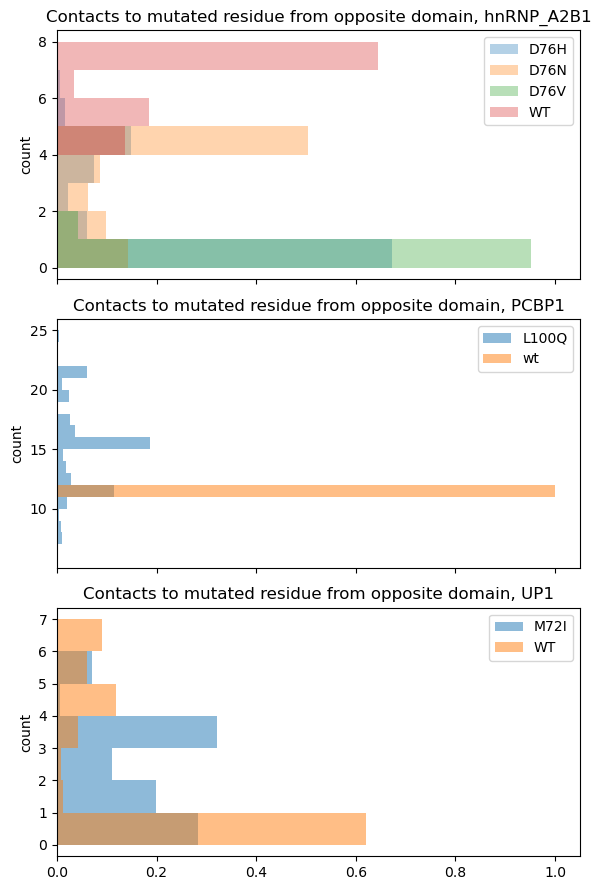

In [49]:
prots = ('hnRNP_A2B1', 'PCBP1', 'UP1')
fig, axs = plt.subplots(len(prots), 1, figsize=(6, 9), sharex=True, layout='tight')
# bins = np.arange(10,25,0.125)
for i, protn in enumerate(prots):
    ax = axs[i]
    # ax.set_xscale('log')
    relvars = [k for k in interdomain_dists_bymodel if protn in k]
    for variant in relvars:
        varname = variant.split('-')[1]
        probs = probs_bymodel[variant]
        point_contacts = contacts_to_point_bymodel[variant]
        # print(variant, dists)
        if len(relvars) > 2:
            alpha = 1/(len(relvars) - 1)
        else:
            alpha = 1/len(relvars)

        pcmax = point_contacts.max()
        pcmin = point_contacts.min()
        print(variant, distmax)
        bins = np.arange(pcmin, pcmax, 1)
        counts,_,_ = ax.hist(point_contacts, bins=bins, weights=probs, 
                label=varname, orientation='horizontal',
                alpha=alpha)
        np.savetxt(datadirp/f'{variant}-contact-mutres-bins.txt', bins)
        np.savetxt(datadirp/f'{variant}-contact-mutres-counts.txt', counts)
    ax.set_title(f'Contacts to mutated residue from opposite domain, {protn}')
    ax.legend()
    ax.set_ylabel('count')
fig.savefig('figures/mutpoint-contact-count-hists.pdf', transparent=True)

## SASA inspection

In [32]:
import mdtraj as md

mutant_resi_md = {
    'PCBP1-L100Q-short-rad-0.30': 'resSeq == 101',
    'PCBP1-wt-short-rad-0.30': 'resSeq == 101',
    'UP1-M72I-short-rad-0.30': 'resSeq == 73',
    'UP1-WT-short-rad-0.30': 'resSeq == 73',
    'hnRNP_A2B1-D76H-rad-0.30': 'resSeq == 63',
    'hnRNP_A2B1-D76N-rad-0.30': 'resSeq == 63',
    'hnRNP_A2B1-D76V-rad-0.30': 'resSeq == 63',
    'hnRNP_A2B1-WT-rad-0.30':  'resSeq == 63'
}

mutpoint_sasa_bymodel = {}
for model_p in sorted(picked_models_p.iterdir()):
    model_n = model_p.name
    print(model_p)
    cens_dir =  cluster_p/f'{model_p.name}/centers'
    trj = md.load(str(cens_dir/'centers.dcd'), top=str(cens_dir/'center0.pdb'))
    mut_iis = trj.top.select(mutant_resi_md[model_n])
    res_sasas = np.array(md.shrake_rupley(trj, mode='residue', atom_indices=mut_iis))
    print(res_sasas[np.where(res_sasas != -1)])
    sasa_ofres = res_sasas[np.where(res_sasas != -1)]
    mutpoint_sasa_bymodel[model_n] = sasa_ofres
    np.savetxt(datadirp/f'{model_n}-sasa-mutres.txt', sasa_ofres)

msms/PCBP1-L100Q-short-rad-0.30
[1.5782759e-02 2.3732163e-02 2.8826687e-02 0.0000000e+00 7.0176788e-02
 5.2356895e-02 8.8488190e-03 3.1213006e-02 5.8884300e-02 2.8075626e-02
 4.2884145e-02 3.5799737e-03 7.6282911e-02 5.4769076e-02 4.2659160e-02
 4.2259876e-02 2.3047267e-02 1.3152218e-01 6.6196255e-02 4.9509987e-02
 5.1138543e-02 2.6800729e-02 8.5573681e-02 7.7498902e-05 4.9358897e-02
 4.5374490e-02 1.3625196e-01 3.1895749e-02 2.6839019e-03 4.8070710e-02
 1.9467402e-02 1.7226350e-05 2.2264419e-02 1.1503465e-02 1.1942108e-01
 3.0195560e-02 2.6546456e-03 1.0620932e-02 6.7549884e-02 2.2162050e-02
 1.4178754e-02 8.8613667e-03 9.0831295e-03 9.4453808e-06 5.6330021e-02
 2.7950032e-02 5.3366306e-03 3.4274526e-02 6.8601437e-02 3.1153245e-02
 9.4587691e-02 8.3650135e-02 4.4931948e-02 2.7472984e-02 2.6500169e-02
 2.7334861e-02 2.6797056e-03 2.6546456e-03 9.6249647e-02 2.7015958e-02
 5.3977795e-02 2.8374130e-02 6.9447950e-02 6.4485162e-02 2.9381013e-02
 7.0952117e-02 1.9975947e-02 2.4794947e-02 3.

hnRNP_A2B1-D76H-rad-0.30 0.2071645 1.3767636 probs (171,) sasas (171,)
[0.2071645 0.2571645 0.3071645 0.3571645 0.4071645 0.4571645 0.5071645
 0.5571645 0.6071645 0.6571645 0.7071645 0.7571645 0.8071645 0.8571645
 0.9071645 0.9571645 1.0071645 1.0571645 1.1071645 1.1571645 1.2071645
 1.2571645 1.3071645 1.3571645]
hnRNP_A2B1-D76N-rad-0.30 0.40635392 1.0478925 probs (73,) sasas (73,)
[0.40635392 0.45635392 0.50635392 0.55635392 0.60635392 0.65635392
 0.70635392 0.75635392 0.80635392 0.85635392 0.90635392 0.95635392
 1.00635392]
hnRNP_A2B1-D76V-rad-0.30 0.41073486 1.1683784 probs (222,) sasas (222,)
[0.41073486 0.46073486 0.51073486 0.56073486 0.61073486 0.66073486
 0.71073486 0.76073486 0.81073486 0.86073486 0.91073486 0.96073486
 1.01073486 1.06073486 1.11073486 1.16073486]
hnRNP_A2B1-WT-rad-0.30 0.3099698 0.52907026 probs (87,) sasas (87,)
[0.30996981 0.35996981 0.40996981 0.45996981 0.50996981]
PCBP1-L100Q-short-rad-0.30 0.0 0.3947579 probs (86,) sasas (86,)
[0.   0.05 0.1  0.15 0.2 

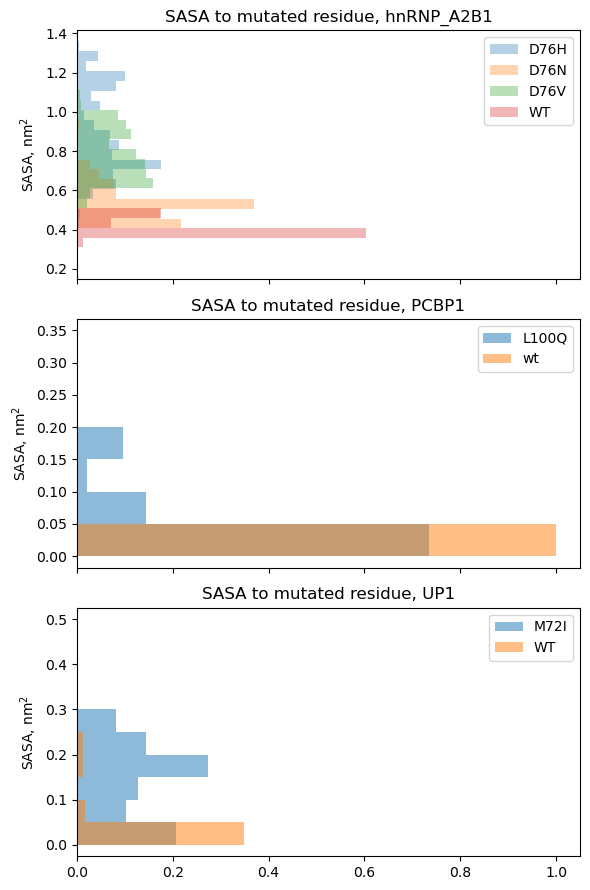

In [41]:
prots = ('hnRNP_A2B1', 'PCBP1', 'UP1')
fig, axs = plt.subplots(len(prots), 1, figsize=(6, 9),
                        sharex=True, layout='tight')
# bins = np.arange(10,25,0.125)
for i, protn in enumerate(prots):
    ax = axs[i]
    # ax.set_xscale('log')
    relvars = [k for k in interdomain_dists_bymodel if protn in k]
    for variant in relvars:
        varname = variant.split('-')[1]
        probs = probs_bymodel[variant]
        sasas = mutpoint_sasa_bymodel[variant]
        if len(relvars) > 2:
            alpha = 1/(len(relvars) - 1)
        else:
            alpha = 1/len(relvars)

        # print(variant, dists)
        sasamax = sasas.max()
        sasamin = sasas.min()
        print(variant, sasamin, sasamax, 'probs',
              probs.shape, 'sasas', sasas.shape)
        bins = np.arange(sasamin, sasamax, 0.05)
        print(bins)
        # bins=10
        counts,_,_ = ax.hist(sasas, bins=bins, weights=probs, 
                                        label=varname, orientation='horizontal',
                                        alpha=alpha)
        np.savetxt(datadirp/f'{variant}-sasa-mutres-bins.txt', bins)
        np.savetxt(datadirp/f'{variant}-sasa-mutres-counts.txt', counts)

    ax.set_title(f'SASA to mutated residue, {protn}')
    ax.legend()
    ax.set_ylabel(r'SASA, $\mathrm{nm^2}$')
fig.savefig('figures/mutpoint-sasa-hists.pdf', transparent=True)